In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [12]:
def f(x):
  return 3*x**2 -4*x +5

In [13]:
f(3.0)

20.0

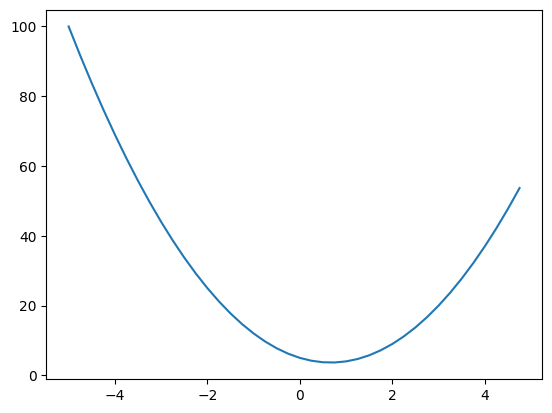

In [14]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs,ys)

In [15]:
h=0.001
x=-3.0
(f(x+h)-f(x))/h

-21.996999999998934

In [16]:
##complex casee
a=2.0
b=-3.0
c=10
d=a*b+c
print(d)

4.0


In [17]:
h=0.0001
a=2.0
b=-3.0
c=10

d1=a*b+c
c+=h
d2=a*b+c


print("d1",d1)
print("d2",d2)
print('slope',(d2-d1)/h)


d1 4.0
d2 4.0001
slope 0.9999999999976694


In [125]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()



In [124]:

a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b;e.label='e'
d=e+c;d.label='d'
f=Value(-2.0,label='f')
L=d*f;L.label='L'

L

Value(data=-8.0)

In [126]:
a=Value(2.0)
b=Value(4.0)
a/b


Value(data=0.5)

In [114]:
a*2

Value(data=4.0)

In [96]:
hasattr(Value, "backward")

True

In [127]:
type(o)

__main__.Value

In [98]:
print(hasattr(Value, "backward"))
print(hasattr(o, "backward"))
print(type(o))

True
False
<class '__main__.Value'>


In [ ]:
o.backward()

In [19]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [20]:
d._op

'+'

In [105]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


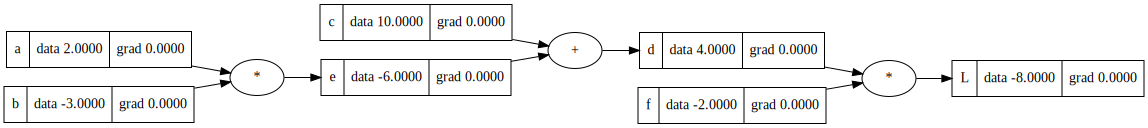

In [106]:
draw_dot(L)

In [23]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad


e=a*b
d=e+c
L=d*f


print(L.data)

-8.0




---



---



---



---



In [24]:
c.grad=-2.0
e.grad=-2.0

In [25]:
a.grad=(-2.0*-3.0)

b.grad=-2.0*2.0

In [26]:
"""dL/de=-2.0
e=a*b
de/da? b



Dl/da=(dL/de)*(de/da)
"""


'dL/de=-2.0\ne=a*b\nde/da? b\n\n\n\nDl/da=(dL/de)*(de/da)\n'

In [27]:
# dd/dc= 1.0
# dd/de = 1.0


# d=c+e

# (f(x+h)-f(x))/h

# ((c+h +e)-(c+e))/h

# (c+h+e-c-e)/h
# h/h


# Want:
# Dl/dc=(dL/dd)*(dd/dc)

# we kow:
# dL/dd
# dd/dc

In [28]:
# L=d*f


# DL/dd=? f
# (f(x+h)-f(x))/h
# ((d+h)*f-d*f)/h

# (d*f+h*d*f-d*f)/h

# (h*f)/h
# f

# DL/df=? d

In [29]:
f.grad=4.0
d.grad=-2.0

In [30]:
L.grad=1

In [31]:
def lol():

  h=0.001
  a=Value(2.0,label='a')
  b=Value(-3.0,label='b')
  c=Value(10.0,label='c')
  e=a*b;e.label='e'
  d=e+c;d.label='d'
  f=Value(-2.0,label='f')
  L=d*f;L.label='L'
  L1=L.data

  a=Value(2.0,label='a')
  b=Value(-3.0,label='b')
  c=Value(10.0,label='c')

  e=a*b;e.label='e'

  e.data +=h
  d=e+c;d.label='d'

  f=Value(-2.0,label='f')
  L=d*f;L.label='L'

  L2=L.data



  print((L2-L1)/h)

lol()

-2.000000000000668




---



---



---



---



# Back Propogation through neural networl

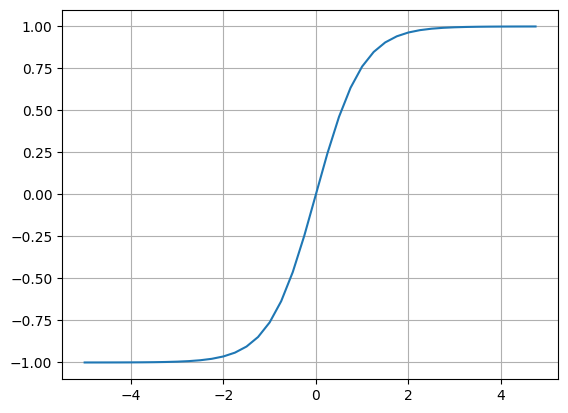

In [32]:
plt.plot(np.arange(-5,5,0.25),np.tanh(np.arange(-5,5,0.25)));plt.grid();

In [78]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

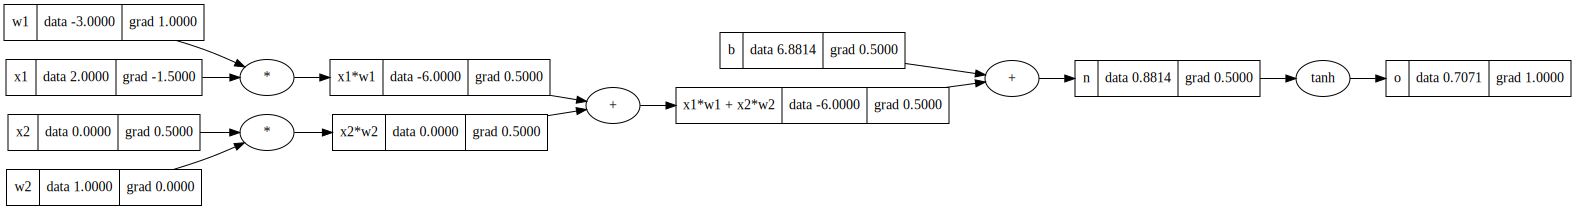

In [107]:
draw_dot(o)

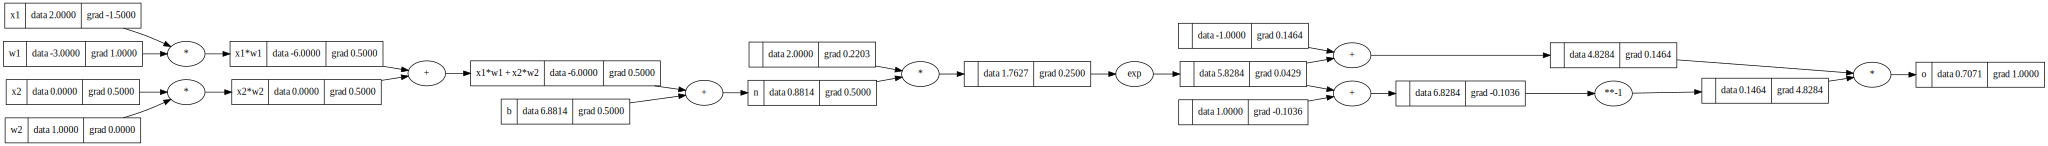

In [128]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e - 1) / (e + 1)

o.label='o'
o.backward()
draw_dot(o)

In [110]:
o.backward()

Successfully ran backward pass!


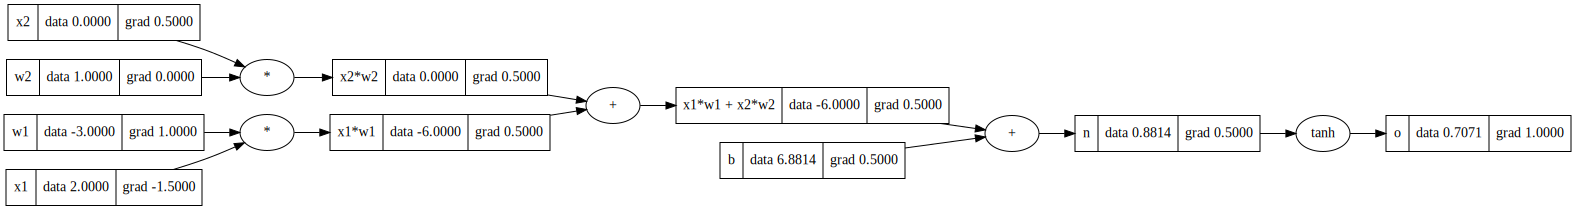

In [109]:
import math

# Re-instantiating the objects so they use the updated Value class definition
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')

# Re-run the operations
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

# Now o.backward() will exist and work correctly
o.backward()
print("Successfully ran backward pass!")
draw_dot(o)

In [92]:
topo=[]
visited=set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [68]:
o.grad=1.0

In [69]:
o._backward()

In [70]:
n._backward()

In [71]:
b._backward()

In [72]:
x1w1x2w2._backward()

In [73]:
x2w2._backward()
x1w1._backward()

In [74]:
x2.grad=w2.data * x2w2.grad
w2.grad=x2.data * x2w2.grad

x1.grad=w1.data * x1w1.grad
w1.grad=x1.data * x1w1.grad

In [36]:
x1w1.grad=0.5
x2w2.grad=0.5

In [37]:
b.grad=0.5
x1w1x2w2.grad=0.5

In [38]:
n.grad=0.5

In [39]:
o.grad=1.0

In [40]:
1-o.data**2

0.4999999999999999

In [41]:
# o=tanh(n)
# do/dn=1-o**2

Doing same thing with pytorch


In [129]:
import torch

In [130]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [134]:
torch.tensor([2.0]).double().dtype

torch.float64

In [135]:
o.item()

0.7071066904050358

In [136]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [141]:
import random

In [147]:

class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [150]:
x = [Value(2.0, label='x1'),
     Value(3.0, label='x2'),
     Value(-1.0, label='x3')]
n=MLP(3,[4,4,1])
n(x)

Value(data=0.8019438396024156)

In [163]:
n.parameters()

[Value(data=0.4182946157162488),
 Value(data=-0.9401800059228704),
 Value(data=0.17365721920673716),
 Value(data=-0.0010888780244961982),
 Value(data=-0.8727086180858183),
 Value(data=0.7226354173773324),
 Value(data=0.5942207202971235),
 Value(data=0.6561771680443236),
 Value(data=0.7814355285631871),
 Value(data=-0.44933940417516416),
 Value(data=-0.43076688054605317),
 Value(data=0.9669229706600182),
 Value(data=0.696552018134722),
 Value(data=0.9591029123717814),
 Value(data=-0.729918851671544),
 Value(data=0.7430876376723603),
 Value(data=-0.39850653465654395),
 Value(data=0.9937915721624639),
 Value(data=-0.7493177562172151),
 Value(data=-0.7567093765690931),
 Value(data=0.959171038270477),
 Value(data=0.9042296954791742),
 Value(data=0.028216410256887148),
 Value(data=0.47172548124505376),
 Value(data=-0.2428038922926774),
 Value(data=0.20281487959120748),
 Value(data=0.25403098691616366),
 Value(data=0.6361397188228137),
 Value(data=0.9022977539116617),
 Value(data=0.7182478352

In [151]:
print(len(n.parameters()))

41


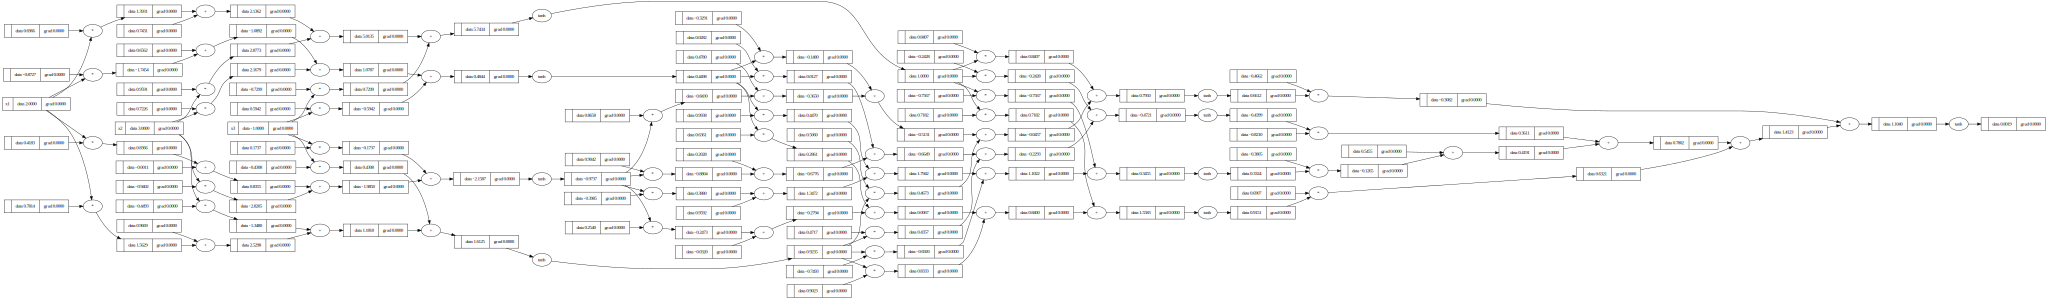

In [152]:
draw_dot(n(x))

In [162]:
# Input → Layer1 → Layer2 → Layer3 → prediction → LOSS
#                                                    ↓
#                                               .backward()
#                                                    ↓
#                                          gradients flow back
#                                                    ↓
#                                          update every weight

In [179]:
xs=[[
    2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],]

ys=[1.0,-1.0,-1.0,1.0]
ypred=[n(x) for x in xs]
ypred

[Value(data=0.9488144272778732),
 Value(data=0.8352930505401184),
 Value(data=0.9161861079859782),
 Value(data=0.9524827641109069)]

In [180]:
ypred=[n(x) for x in xs]

loss=sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.044947632360735)

In [177]:
ypred=[n(x) for x in xs]

loss=sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.044947632360735)

In [178]:
loss.backward()

In [160]:
n.layers[0].neurons[0].w[0]

Value(data=0.4182946157162488)

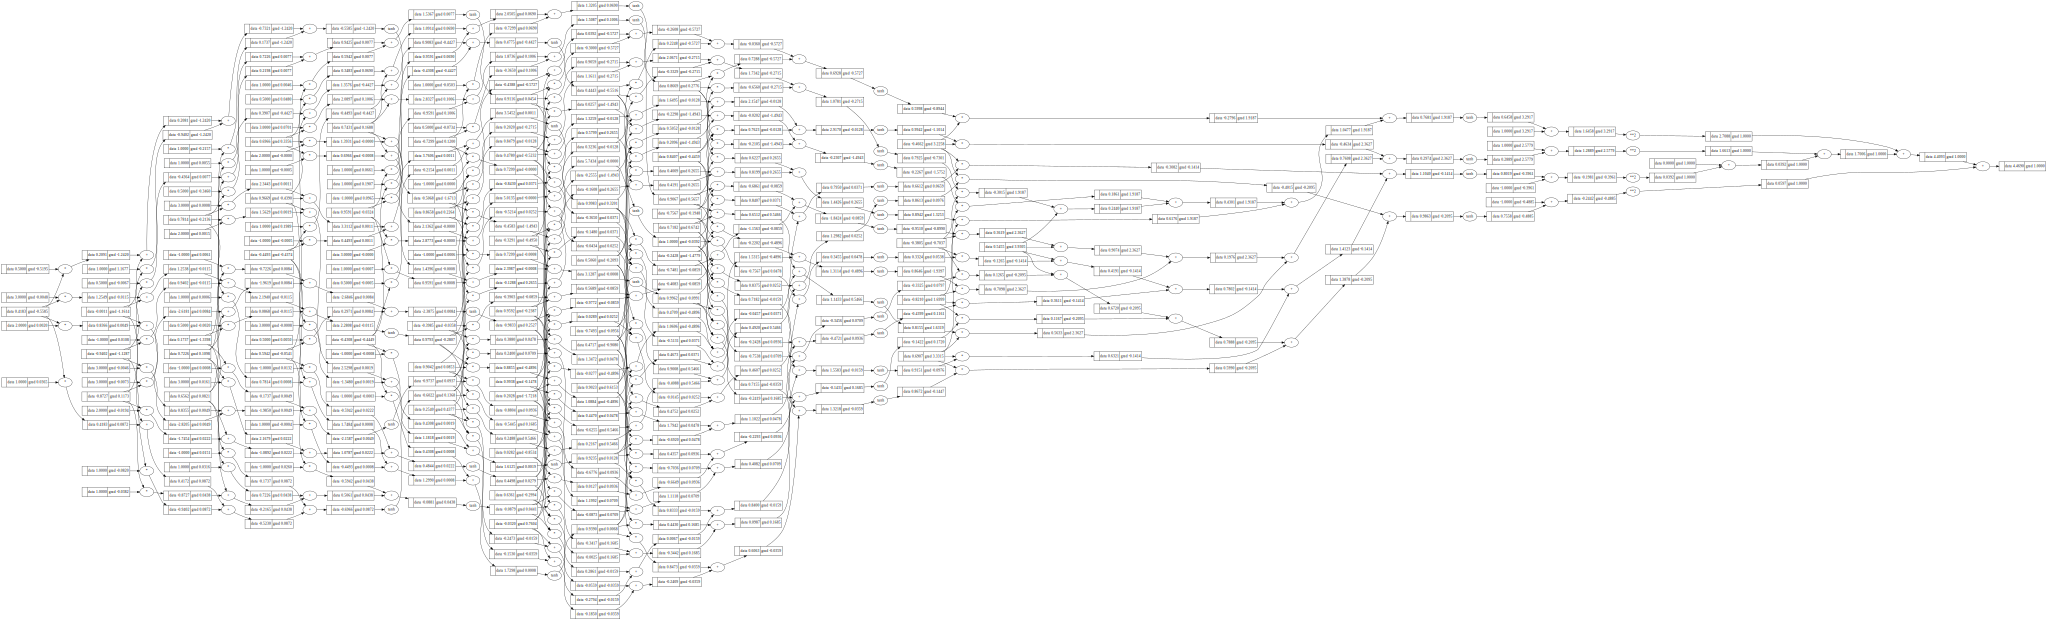

In [161]:
draw_dot(loss)

In [165]:
n.layers[0].neurons[0].w[0].data

0.41270931739952954

In [176]:
for p in n.parameters():
  p.data += 0.01 * p.grad



In [167]:
n.layers[0].neurons[0].w[0].data

0.40712401908281026

In [181]:

for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)


0 7.044947632360735
1 5.740963085846394
2 2.7028342348877294
3 1.2996802460047925
4 1.506313467968103
5 1.885482466536865
6 1.6640323487216544
7 0.040369444304593216
8 0.03372818492675013
9 0.029376914628526138
10 0.02628747600871984
11 0.023965696880867183
12 0.022144605572652964
13 0.02066766262782911
14 0.01943729945744107
15 0.01838973455148263
16 0.017481635631212772
17 0.016682604379236625
18 0.015970725309685612
19 0.015329818889858553


In [184]:
ypred

[Value(data=0.9354914979464765),
 Value(data=-0.9267750740187242),
 Value(data=-0.9767503500401397),
 Value(data=0.9274325414221378)]